In [67]:
import pandas as pd
import os
from geneeanlpclient import g3
import requests
from dotenv import load_dotenv
from datetime import datetime
import time
import json
from datetime import datetime
from collections import Counter
import matplotlib.pyplot as plt


In [34]:

load_dotenv()
geneeaKey = os.environ["GENEEA_USER_KEY"]
kaggleKey = os.environ["KAGGLE_KEY"]

In [35]:
def callGeneea(input):
    url = 'https://api.geneea.com/v3/analysis'
    headers = {
        'content-type': 'application/json',
        'Authorization': 'user_key ' + geneeaKey
    }
    return requests.post(url, json=input, headers=headers).json()

In [21]:
trueData = pd.read_csv("True.csv")
fakeData = pd.read_csv("Fake.csv")

In [22]:
trueData["date"] = pd.to_datetime(trueData["date"], errors="coerce", format="mixed")
fakeData["date"] = pd.to_datetime(fakeData["date"], errors="coerce", format="mixed")

In [25]:
trueData.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,2017-12-31
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,2017-12-29
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,2017-12-31
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,2017-12-30
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,2017-12-29


In [30]:
try:
    with open("Geneaa_Results_True.json") as f:
        trueGeneea = json.load(f)

    with open("SeenData.json") as f:
        seen = set(json.load(f))
except:
    trueGeneea = dict()
    seen = set()

In [37]:
target = datetime.strptime("03/28/2017", "%m/%d/%Y")

targetData = trueData[((trueData["date"].dt.month == target.month)  & (trueData["date"].dt.year == target.year)) & (trueData["date"].dt.day == target.day)]

In [115]:
def getGroupWithAttr(targetData, attr=None, outputTitle="out.json"):
    try:
        with open(outputTitle) as f:
            geneeaOut = json.load(f)
    except FileNotFoundError:
        geneeaOut = dict()

    seen = set(geneeaOut.keys())
  
    for _, each in targetData.iterrows():
        title = each['title']
        if (title in seen):
            continue
        
        doc = callGeneea({"text": each['text'], "analyses": attr})
        if "exception" in doc:
            print(doc.get("exception"))
            break
        geneeaOut[title] = doc
        seen.add(title)
        with open(outputTitle, "w") as f:
            json.dump(geneeaOut, f)
        time.sleep(1)

def getGroup(targetData, outputTitle):
    getGroupWithAttr(targetData, ['entities', 'tags', 'relations', 'sentiment'], outputTitle)

In [ ]:
getGroup(targetData, "Geneaa_Results_True.json")

In [142]:
loc_count = Counter()
for each in trueGeneea.values():
    if "entities" in each:
        for e in each["entities"]:
            if e.get("type") == "location":
                loc_count[e["stdForm"]] += 1

print(loc_count.most_common(5))


[('United States of America', 408), ('WASHINGTON', 337), ('White House', 229), ('Washington', 94), ('Russia', 69)]


In [143]:
person_count = Counter()
for each in trueGeneea.values():
    if "entities" in each:
        for e in each["entities"]:
            if e.get("type") == "person":
                person_count[e["stdForm"]] += 1

print(person_count.most_common(5))

[('Donald Trump', 404), ('Barack Obama', 171), ('Obamacare', 59), ('Paul Ryan', 53), ('Rex Tillerson', 53)]


In [144]:
top5_people = {name for name, _ in person_count.most_common(5)}
person_count.most_common(5)

[('Donald Trump', 404),
 ('Barack Obama', 171),
 ('Obamacare', 59),
 ('Paul Ryan', 53),
 ('Rex Tillerson', 53)]

{'Barack Obama', 'Obamacare', 'Paul Ryan', 'Donald Trump', 'Rex Tillerson'}


Text(0, 0.5, 'Frequency')

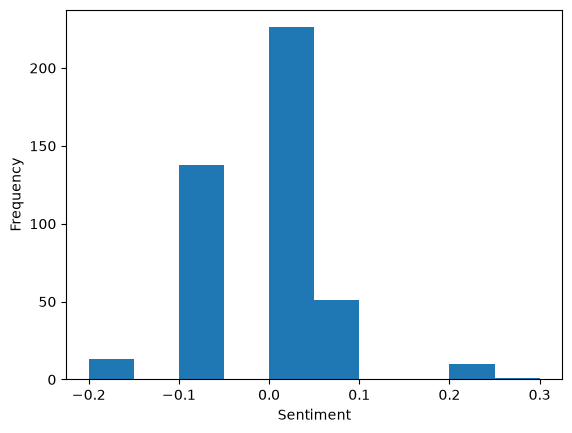

In [145]:
trueSent = []

for each in trueGeneea.values():
    if "entities" in each:
        for e in each["entities"]:
            if e.get("type") == "person" and e["stdForm"] in top5_people:
                trueSent.append(each.get("docSentiment").get("mean"))
                break


print(top5_people)
plt.hist(trueSent, bins=10)
plt.xlabel("Sentiment")
plt.ylabel("Frequency")

In [ ]:
target = datetime.strptime("03/2017", "%m/%Y")

targetData = trueData[((trueData["date"].dt.month == target.month)  & (trueData["date"].dt.year == target.year))]

getGroupWithAttr(targetData, ['entities', 'sentiment'], "Geneea_Results_True.json")

In [166]:
with open("Geneea_Results_True.json") as f:
    trueGeneea = json.load(f)

len(trueGeneea)

517

In [135]:
print('bisexual' in loc_count.keys())

False


In [191]:
def worstSent(data):
    worstSentiment = ("", 0)
    for key in data.keys():
        sent = data[key].get("docSentiment")
        if sent is None:
            continue
        sent = sent.get("mean")
        if sent < worstSentiment[1]:
            worstSentiment = (key, sent) 
    return worstSentiment

In [153]:
bestSentiment = ("", 0)
for key in trueGeneea.keys():
    sent = trueGeneea[key].get("docSentiment")
    if sent is None:
        continue
    sent = sent.get("mean")
    if sent > bestSentiment[1]:
       bestSentiment = (key, sent) 

print(bestSentiment)

('Lockheed Martin wins $582 million U.S. defense contract: Pentagon', 0.3)


In [165]:
worstSentiment = worstSent(trueGeneea)
doc = callGeneea({"text": trueData[trueData["title"] == worstSentiment[0]]["text"].iloc[0], "analyses": ['entities', 'tags', 'relations', 'sentiment']})

trueGeneea[worstSentiment[0]] = doc

with open("Geneea_Results_True.json", "w") as f:
    json.dump(trueGeneea, f)

In [180]:
relations = trueGeneea[worstSentiment[0]].get("relations")
rel_count = Counter()

for each in relations:
    rel_count[each.get("name")] +=1
print(rel_count)

Counter({'face': 5, 'pay': 3, 'former': 3, 'involve': 3, 'decline': 3, 'real estate': 2, 'say': 2, 'extend': 2, 'accuse': 2, 'take': 2, 'plea talk': 1, 'disclose': 1, 'seek': 1, 'that consider': 1, 'civil': 1, 'come': 1, 'substantial': 1, 'plead': 1, 'accept': 1, 'pursue': 1, 'one': 1, 'relate': 1, 'die': 1, 'await': 1, 'deputy': 1, 'have': 1, 'obtain': 1, 'back': 1, 'develop': 1, 'main': 1, 'evade': 1, 'conceal': 1, 'deny': 1, 'base': 1})


In [184]:
mostMentioned = {name for name, _ in rel_count.most_common(10)}
for each in relations:
    if each.get("name") in mostMentioned:
        print(each.get("textRepr") + "\n")

pay(bribes)

former(president)

real estate(billionaire estate developer)

say(lawyer)

extend(prosecutor)

involve(Jeff Yin)

extend(court deadline)

involve(tax assessment)

involve(liability)

could face(Jeff Yin,prison time)

face(he,bribery charge)

face(he,related)

face(he,money laundering)

decline(Sabrina Shroff,comment)

decline(comment)

former(President)

accuse(prosecutor,Ng)

accuse(prosecutor,Jeff Yin)

former(U.N. ambassador)

say(indictment)

pay(Ng,bribes)

take(ambassador,step)

face(charge)

pay(income taxes)

take(step)

real estate(estate developer)

decline(lawyer)



In [185]:
target = datetime.strptime("08/11/2016", "%d/%m/%Y")

targetDataFake = fakeData[fakeData["date"] == target]

In [ ]:
getGroup(targetData, "Geneea_Results_Fake.json")

In [189]:
with open("Geneea_Results_Fake.json") as f:
    fakeGeneea = json.load(f)

len(fakeGeneea)

105

In [192]:
worstSentiment = worstSent(fakeGeneea)
worstSentiment

('Schiff says accepted White House invitation to review intelligence', -0.2)

[('Donald Trump', 83), ('Barack Obama', 30), ('Paul Ryan', 13), ('Devin Nunes', 10), ('Sean Spicer', 9)]


Text(0, 0.5, 'Frequency')

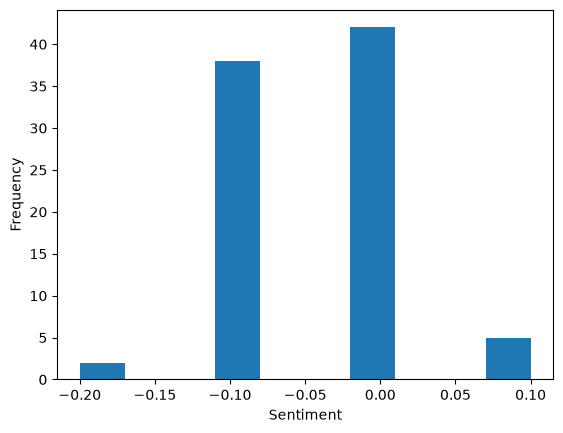

In [195]:
fake_person_count = Counter()

for each in fakeGeneea.values():
    if "entities" in each:
        for e in each["entities"]:
            if e.get("type") == "person":
                fake_person_count[e["stdForm"]] += 1

fakeTop5 = [name for name, _ in fake_person_count.most_common(5)]

fakeSent = []
for each in fakeGeneea.values():
    if "entities" in each:
        for e in each["entities"]:
            if e.get("type") == "person" and e["stdForm"] in top5_people:
                fakeSent.append(each.get("docSentiment").get("mean"))
                break


print(fake_person_count.most_common(5))
plt.hist(fakeSent, bins=10)
plt.xlabel("Sentiment")
plt.ylabel("Frequency")

[('Donald Trump', 83), ('Barack Obama', 30), ('Paul Ryan', 13), ('Devin Nunes', 10), ('Sean Spicer', 9)]


Text(0, 0.5, 'Frequency')

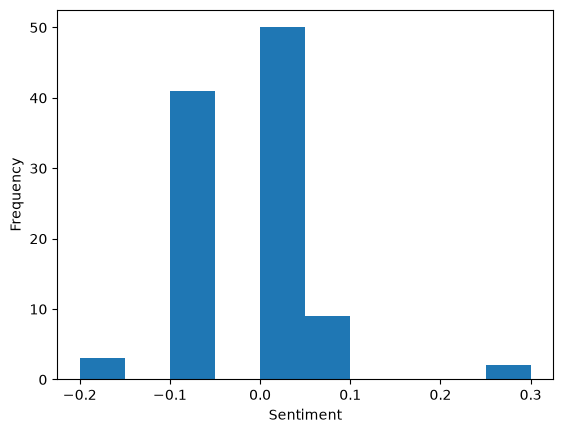

In [197]:
fakeSent = []
for each in fakeGeneea.values():
    fakeSent.append(each.get("docSentiment").get("mean"))


plt.hist(fakeSent, bins=10)
plt.xlabel("Sentiment")
plt.ylabel("Frequency")

In [200]:
relations = fakeGeneea[worstSentiment[0]].get("relations")
fake_rel_count = Counter()

for each in relations:
    fake_rel_count[each.get("name")] +=1
print(fake_rel_count)

Counter({'say': 2, 'accept': 1, 'review': 1, 'same': 1, 'Republican': 1, 'top': 1, 'Representative': 1, 'have': 1, 'pass': 1, 'congressional': 1, 'raise': 1, 'profound': 1})


In [201]:
mostMentioned = {name for name, _ in fake_rel_count.most_common(10)}
for each in relations:
    if each.get("name") in mostMentioned:
        print(each.get("textRepr") + "\n")

say(Democrat)

accept(he,invitation)

review(intelligence information)

same(information)

Republican(chairman)

top(Democrat)

say(Adam Schiff)

Representative(Adam Schiff)

have(White House staff)

pass(reason,information)

congressional(committee chairman)

